# Contrafactuais — módulo 04

Explicações contrafactuais — Molnar, *Interpretable Machine Learning*,
cap. 15; Wachter et al. (2018) — sobre **o modelo do curso** (módulo 00).
Este módulo é novo: não tem versão Breast Cancer no histórico.

Os módulos 01–03 perguntaram *"o que pesou nesta predição?"*. O
contrafactual inverte: **"o que teria de ser diferente para a predição
mudar?"** — e a inversão muda o que as cercas significam. Até aqui,
paciente impossível era diagnóstico de método doente; aqui a
impossibilidade vira **restrição de busca**, e ganha uma irmã que a
`gate_impossible` não vê: a **acionabilidade**.

Sem biblioteca: a busca é exaustiva, na mão. O espaço deste problema é
pequeno (≈100 mudanças simples, ≈2.000 pares úteis — uma chamada de
predição em lote), e exaustão determinística domina busca genética
estocástica quando cabe na memória: cobertura completa em profundidade 2,
zero sementes. DiCE (Mothilal et al., 2020) não roda aqui — a versão
publicada não resolve contra o numpy 2.x do stack pinado — e a decisão de
não pinar para trás está registrada no PR do pin.

In [1]:
%pip install -q xgboost scikit-learn matplotlib numpy pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pathlib
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
RANDOM_STATE = 42

REPO = pathlib.Path.cwd()
while REPO != REPO.parent and not (REPO / "tools" / "srag_model.py").exists():
    REPO = REPO.parent
if not (REPO / "tools" / "srag_model.py").exists():
    import tempfile
    REPO = pathlib.Path(tempfile.gettempdir()) / "interpretable-ml-lectures"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/wbendinelli/interpretable-ml-lectures.git",
                        str(REPO)], check=True)
sys.path.insert(0, str(REPO / "tools"))
import srag_model as M

FIGDIR = pathlib.Path("figures_generated")
FIGDIR.mkdir(exist_ok=True)

g = M.load_gold(REPO / "modules/00-dataset/gold/gold_covid_obito_sample.parquet")
xgb, _logit = M.fit_models(g)

# o paciente deste módulo, POR REGRA: contrafactual pede alguém com o que
# perder — p mais próximo de 0,8 no teste, empate por gold_id
teste = g[g["split"] == "test"].reset_index(drop=True)
p_teste = M.predict_proba(xgb, teste)
ordem = np.lexsort((teste["gold_id"].to_numpy(), np.abs(p_teste - 0.8)))
alto = teste.iloc[ordem[0]].copy()
alto["p_obito"] = float(p_teste[ordem[0]])

print(f"paciente de alto risco: gold_id {int(alto['gold_id'])}  "
      f"p(óbito) {alto['p_obito']:.4f}")
print(f"  idade {alto['idade_anos']:.0f} | doses {int(alto['n_doses_antes_do_sintoma'])} | "
      f"meses desde mar/2020 {alto['meses_desde_mar2020']:.1f} | "
      f"fator de risco declarado: {bool(alto['fator_risc_portao'])}")
comorbs = [c for c in M.CATEGORICAS[5:18] if str(alto[c]) == "sim"]
sintomas = [c for c in M.CATEGORICAS[18:31] if str(alto[c]) == "sim"]
print(f"  comorbidades sim: {comorbs}")
print(f"  sintomas sim: {sintomas}")

paciente de alto risco: gold_id 1267430  p(óbito) 0.8043
  idade 81 | doses 3 | meses desde mar/2020 46.3 | fator de risco declarado: True
  comorbidades sim: ['pneumopati', 'imunodepre', 'out_morbi']
  sintomas sim: ['febre', 'tosse', 'dispneia', 'desc_resp', 'saturacao', 'vomito', 'fadiga']


## §1 — O espaço de busca, declarado

Movimentos por feature: idade em passos de 10, doses 0–6, meses em passos
de 6, booleanas nos dois valores, categóricas em todos os níveis.
`semana_epi` fica fora — é atrelada a `meses_desde_mar2020`, e mover uma
sem a outra fabricaria um calendário que não existe (a lição do módulo 03
aplicada ao desenho da busca, antes de medir).

Primeiro a busca corre **livre** — tudo pode mudar — para ver o que o
método *quer*. Os filtros vêm depois, um de cada vez, com contagem.

In [3]:
MOVES = {}
MOVES["idade_anos"] = [float(v) for v in range(0, 101, 10)]
MOVES["n_doses_antes_do_sintoma"] = [float(v) for v in range(0, 7)]
MOVES["meses_desde_mar2020"] = [float(v) for v in range(0, 59, 6)]
for c in M.BOOLEANAS:
    MOVES[c] = [False, True]
for c in M.CATEGORICAS:
    MOVES[c] = list(g[c].cat.categories)
# semana_epi fica fora: é atrelada a meses_desde_mar2020 — mover uma sem a
# outra fabricaria um calendário que não existe

GRUPO = {}
for c in M.CATEGORICAS[:5]:
    GRUPO[c] = "demografia"
for c in M.CATEGORICAS[5:18]:
    GRUPO[c] = "comorbidade"
for c in M.CATEGORICAS[18:31]:
    GRUPO[c] = "sintoma"
for c in M.CATEGORICAS[31:34]:
    GRUPO[c] = "contexto"
GRUPO.update({"idade_anos": "demografia", "meses_desde_mar2020": "tempo",
              "n_doses_antes_do_sintoma": "dose", "vacina_covid_declarada": "dose",
              "coinfeccao_outro_virus": "comorbidade"})


def candidatos_1(pac):
    out = []
    for c, vals in MOVES.items():
        for v in vals:
            if c in M.CATEGORICAS:
                if str(v) == str(pac[c]):
                    continue
            elif float(v) == float(pac[c]):
                continue
            out.append((c, v))
    return out


def aplicar(pac, lista_de_mudancas):
    """cada item é uma lista [(coluna, valor), ...]; devolve um frame."""
    linhas = []
    modelo_linha = {c: pac[c] for c in g.columns}
    for muds in lista_de_mudancas:
        linha = dict(modelo_linha)
        for c, v in muds:
            linha[c] = v
        linhas.append(linha)
    df = pd.DataFrame(linhas)
    return df.astype(g.dtypes)


c1 = candidatos_1(alto)
print(f"movimentos simples possíveis para este paciente: {len(c1)}")
n_grupos = pd.Series([GRUPO[c] for c, _ in c1]).value_counts()
print(n_grupos.to_string())

movimentos simples possíveis para este paciente: 113
demografia     33
comorbidade    27
sintoma        26
tempo          10
contexto       10
dose            7


## §2 — Profundidade 1: o que a busca livre quer

Uma mudança por vez. A pergunta que o gráfico responde: se o modelo
pudesse pedir qualquer coisa, o que pediria?

as 10 mudanças simples que mais derrubam a predição:
  idade_anos -> 10.0: p 0.804 -> 0.480 (demografia)
  idade_anos -> 0.0: p 0.804 -> 0.547 (demografia)
  saturacao -> nao: p 0.804 -> 0.573 (sintoma)
  dispneia -> nao: p 0.804 -> 0.581 (sintoma)
  saturacao -> desconhecido: p 0.804 -> 0.605 (sintoma)
  cs_raca -> desconhecido: p 0.804 -> 0.611 (demografia)
  cs_escol_n -> desconhecido: p 0.804 -> 0.661 (demografia)
  cs_escol_n -> nao_se_aplica: p 0.804 -> 0.663 (demografia)
  cs_escol_n -> fundamental_2: p 0.804 -> 0.676 (demografia)
  nosocomial -> desconhecido: p 0.804 -> 0.678 (contexto)

inválidos pela gate_impossible: 3.5% dos 113
mudanças simples que cruzam 0,5 e passam na cerca: 1


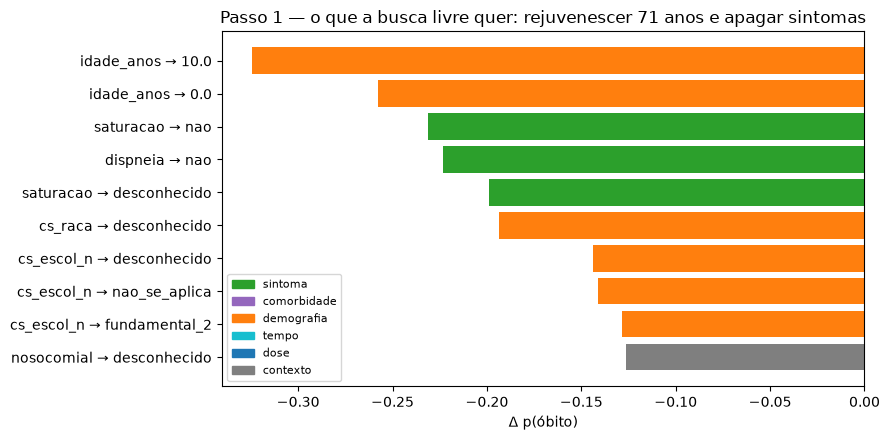

In [4]:
f1 = aplicar(alto, [[m] for m in c1])
p1 = M.predict_proba(xgb, f1)
delta = p1 - alto["p_obito"]
invalido1 = M.gate_impossible(f1).to_numpy()

melhores = np.argsort(delta)[:10]
print("as 10 mudanças simples que mais derrubam a predição:")
for i in melhores:
    c, v = c1[i]
    marca = "  [INVÁLIDO pela cerca]" if invalido1[i] else ""
    print(f"  {c} -> {v}: p {alto['p_obito']:.3f} -> {p1[i]:.3f} ({GRUPO[c]}){marca}")
cruzam = ((p1 < 0.5) & ~invalido1).sum()
print(f"\ninválidos pela gate_impossible: {100 * invalido1.mean():.1f}% dos {len(c1)}")
print(f"mudanças simples que cruzam 0,5 e passam na cerca: {cruzam}")

CORES = {"sintoma": "tab:green", "comorbidade": "tab:purple",
         "demografia": "tab:orange", "tempo": "tab:cyan", "dose": "tab:blue",
         "contexto": "tab:gray"}
fig, ax = plt.subplots(figsize=(9, 4.5))
nomes = [f"{c1[i][0]} → {c1[i][1]}" for i in melhores][::-1]
vals = [delta[i] for i in melhores][::-1]
cores = [CORES[GRUPO[c1[i][0]]] for i in melhores][::-1]
ax.barh(nomes, vals, color=cores)
ax.set_xlabel("Δ p(óbito)")
ax.set_title("Passo 1 — o que a busca livre quer: rejuvenescer 71 anos e apagar sintomas")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in CORES.values()]
ax.legend(handles, CORES.keys(), loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "cf_passo_1_busca_livre.png", dpi=150, bbox_inches="tight")
plt.show()

## §3 — Profundidade 2: "válido" não é "acionável"

Pares sobre os 60 melhores movimentos. Repare no que os melhores
contrafactuais **válidos** pedem: são pacientes que *podem existir* — uma
criança de 10 anos sem imunodepressão existe, uma gestante de terceiro
trimestre existe — mas **não são alcançáveis a partir de quem o paciente
é**. A `gate_impossible` responde "isso existe?"; ela não foi desenhada
para responder "dá para chegar lá?". Dois filtros, duas perguntas — o
módulo 03 mediu o primeiro; este módulo existe por causa do segundo.

pares avaliados: 1706 | inválidos: 3.4% | cruzam 0,5 válidos: 151

os 5 melhores contrafactuais 'válidos' — leia com atenção:
  idade_anos → 10.0 + imunodepre → nao: p -> 0.182
  idade_anos → 10.0 + imunodepre → desconhecido: p -> 0.188
  idade_anos → 10.0 + cs_gestant → 3_trimestre: p -> 0.203
  idade_anos → 10.0 + dispneia → nao: p -> 0.221
  idade_anos → 10.0 + saturacao → nao: p -> 0.222


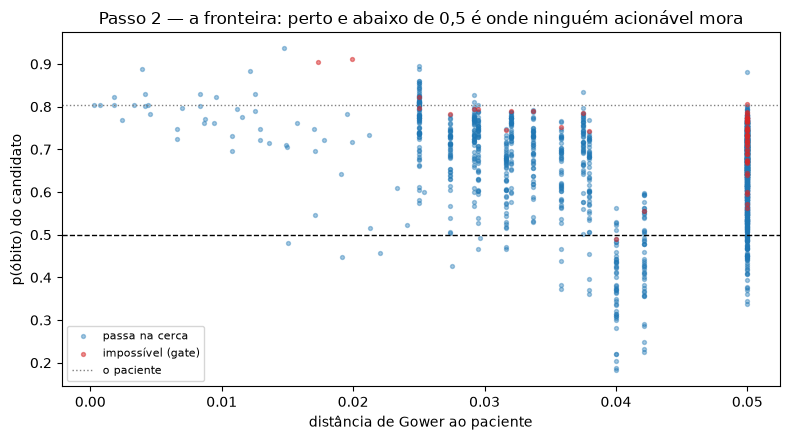

In [5]:
top60 = list(np.argsort(delta)[:60])
pares = [[c1[i], c1[j]] for a, i in enumerate(top60)
         for j in top60[a + 1:] if c1[i][0] != c1[j][0]]
f2 = aplicar(alto, pares)
p2 = M.predict_proba(xgb, f2)
invalido2 = M.gate_impossible(f2).to_numpy()
ok2 = (p2 < 0.5) & ~invalido2
print(f"pares avaliados: {len(pares)} | inválidos: {100 * invalido2.mean():.1f}% | "
      f"cruzam 0,5 válidos: {ok2.sum()}")
print("\nos 5 melhores contrafactuais 'válidos' — leia com atenção:")
mostrados = 0
for i in np.argsort(p2):
    if not ok2[i]:
        continue
    desc = " + ".join(f"{c} → {v}" for c, v in pares[i])
    print(f"  {desc}: p -> {p2[i]:.3f}")
    mostrados += 1
    if mostrados >= 5:
        break

NUM_G = list(M.NUMERICAS)
CAT_G = list(M.CATEGORICAS) + list(M.BOOLEANAS)
FAIXAS = {c: float(g[c].max() - g[c].min()) or 1.0 for c in NUM_G}


def gower_par(pac, frame):
    """Gower paciente ↔ cada linha do frame, nas 40 features (par a par —
    a mesma família de métrica do módulo 01, que media ao vizinho real)."""
    d = np.zeros(len(frame))
    for c in NUM_G:
        d += np.abs(frame[c].to_numpy(dtype=float) - float(pac[c])) / FAIXAS[c]
    for c in CAT_G:
        d += (frame[c].astype(str).to_numpy() != str(pac[c])).astype(float)
    return d / (len(NUM_G) + len(CAT_G))


g1, g2 = gower_par(alto, f1), gower_par(alto, f2)
fig, ax = plt.subplots(figsize=(8, 4.5))
todos_p = np.concatenate([p1, p2])
todos_g = np.concatenate([g1, g2])
todos_inv = np.concatenate([invalido1, invalido2])
ax.scatter(todos_g[~todos_inv], todos_p[~todos_inv], s=8, alpha=0.4,
           color="tab:blue", label="passa na cerca")
ax.scatter(todos_g[todos_inv], todos_p[todos_inv], s=8, alpha=0.5,
           color="tab:red", label="impossível (gate)")
ax.axhline(0.5, color="black", lw=1, ls="--")
ax.axhline(alto["p_obito"], color="gray", lw=1, ls=":", label="o paciente")
ax.set_xlabel("distância de Gower ao paciente")
ax.set_ylabel("p(óbito) do candidato")
ax.set_title("Passo 2 — a fronteira: perto e abaixo de 0,5 é onde ninguém acionável mora")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGDIR / "cf_passo_2_fronteira.png", dpi=150, bbox_inches="tight")
plt.show()

## §4 — As alavancas reais

O que uma pessoa (ou uma política de saúde) de fato controla neste vetor:
o histórico vacinal **antes do sintoma** — doses para cima, nunca para
baixo — e a declaração dele. Idade, sexo, comorbidades registradas,
sintomas (consequência, não causa) e o calendário não são alavancas.

A pergunta honesta do módulo: **para quantos pacientes de alto risco
existe um contrafactual acionável?** — medida em todo o split de teste.

candidatos acionáveis do paciente de alto risco: 3
  n_doses_antes_do_sintoma → 4.0: p -> 0.829
  n_doses_antes_do_sintoma → 5.0: p -> 0.829
  n_doses_antes_do_sintoma → 6.0: p -> 0.829
algum cruza 0,5? False — o melhor chega a 0.829

pacientes do teste com p >= 0,5: 902 de 16142


com contrafactual ACIONÁVEL que cruza 0,5: 325 (36.0%)
sem nada ao alcance que mude a previsão: 577 (64.0%)

fração com contrafactual acionável, por banda de risco:
             mean  count
banda                   
0,5–0,6  0.431090    624
0,6–0,7  0.250000    216
0,7+     0.032258     62


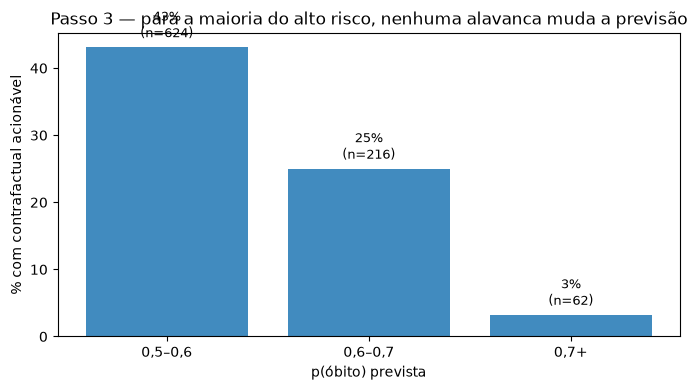

In [6]:
ALAVANCAS = ("n_doses_antes_do_sintoma", "vacina_covid_declarada")


def candidatos_acionaveis(pac):
    """doses só para CIMA (o passado vacinal poderia ter sido maior, nunca
    menor) e a declaração junto; nada mais é alcançável por decisão."""
    d0 = int(pac["n_doses_antes_do_sintoma"])
    cand = [[("n_doses_antes_do_sintoma", float(d))] for d in range(d0 + 1, 7)]
    if not bool(pac["vacina_covid_declarada"]):
        cand += [[("vacina_covid_declarada", True)]]
        cand += [[("n_doses_antes_do_sintoma", float(d)),
                  ("vacina_covid_declarada", True)] for d in range(d0 + 1, 7)]
    return cand


cand_alto = candidatos_acionaveis(alto)
fa = aplicar(alto, cand_alto)
pa = M.predict_proba(xgb, fa)
print(f"candidatos acionáveis do paciente de alto risco: {len(cand_alto)}")
for muds, p in zip(cand_alto, pa):
    desc = " + ".join(f"{c} → {v}" for c, v in muds)
    print(f"  {desc}: p -> {p:.3f}")
print(f"algum cruza 0,5? {bool((pa < 0.5).any())} — o melhor chega a {pa.min():.3f}")

# o mesmo teste para TODO paciente de alto risco do split de teste
p_todos = M.predict_proba(xgb, teste)
alto_risco = teste[p_todos >= 0.5].reset_index(drop=True)
print(f"\npacientes do teste com p >= 0,5: {len(alto_risco)} de {len(teste)}")

blocos, indices = [], []
for k in range(len(alto_risco)):
    pac_k = alto_risco.iloc[k]
    cand_k = candidatos_acionaveis(pac_k)
    if cand_k:
        blocos.append(aplicar(pac_k, cand_k))
        indices.extend([k] * len(cand_k))
lote = pd.concat(blocos, ignore_index=True)
p_lote = M.predict_proba(xgb, lote)
flip = pd.Series(p_lote < 0.5).groupby(np.asarray(indices)).any()
com_cf = int(flip.sum())
print(f"com contrafactual ACIONÁVEL que cruza 0,5: {com_cf} "
      f"({100 * com_cf / len(alto_risco):.1f}%)")
print(f"sem nada ao alcance que mude a previsão: {len(alto_risco) - com_cf} "
      f"({100 * (1 - com_cf / len(alto_risco)):.1f}%)")

p_ar = p_todos[p_todos >= 0.5]
bandas = pd.cut(p_ar, [0.5, 0.6, 0.7, 1.0], labels=["0,5–0,6", "0,6–0,7", "0,7+"])
tab = pd.DataFrame({"banda": bandas, "flip": flip.reindex(range(len(alto_risco)),
                                                          fill_value=False).to_numpy()})
resumo = tab.groupby("banda", observed=True)["flip"].agg(["mean", "count"])
print("\nfração com contrafactual acionável, por banda de risco:")
print(resumo.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(resumo.index.astype(str), 100 * resumo["mean"], color="tab:blue", alpha=0.85)
for x, (m, n) in enumerate(zip(resumo["mean"], resumo["count"])):
    ax.text(x, 100 * m + 1.5, f"{100 * m:.0f}%\n(n={n})", ha="center", fontsize=9)
ax.set_ylabel("% com contrafactual acionável")
ax.set_xlabel("p(óbito) prevista")
ax.set_title("Passo 3 — para a maioria do alto risco, nenhuma alavanca muda a previsão")
fig.tight_layout()
fig.savefig(FIGDIR / "cf_passo_3_painel.png", dpi=150, bbox_inches="tight")
plt.show()

## §5 — Perto, possível, alcançável

Wachter et al. propõem minimizar perda de predição + distância; DiCE
acrescenta diversidade e proximidade. A tabela abaixo mostra por que
distância não decide: o candidato **mais próximo** de todos é o acionável
— e não cruza o limiar; os livres são quase tão próximos e absurdos como
prescrição. Proximidade (Wachter), existência (`gate_impossible`) e
acionabilidade (a lista de alavancas) são três filtros diferentes, e só o
terceiro é sobre o paciente real.

In [7]:
melhor_1 = int(np.argmin(p1))
val2 = np.where(ok2)[0]
melhor_2 = int(val2[np.argmin(p2[val2])])
linhas = pd.concat([f1.iloc[[melhor_1]], f2.iloc[[melhor_2]],
                    fa.iloc[[int(np.argmin(pa))]]], ignore_index=True)
gs = gower_par(alto, linhas)
ps = [float(p1[melhor_1]), float(p2[melhor_2]), float(pa.min())]
rotulos = ["melhor 1 mudança (livre)", "melhor par válido (livre)",
           "melhor acionável"]
descrs = [f"{c1[melhor_1][0]} → {c1[melhor_1][1]}",
          " + ".join(f"{c} → {v}" for c, v in pares[melhor_2]),
          " + ".join(f"{c} → {v}" for c, v in cand_alto[int(np.argmin(pa))])]
print("candidato                      p final   Gower   mudanças")
for r, d, p, dist, n_m in zip(rotulos, descrs, ps, gs, (1, 2, len(cand_alto[int(np.argmin(pa))]))):
    print(f"{r:30s} {p:7.3f}  {dist:6.4f}   {d}")
print(f"\np do paciente: {alto['p_obito']:.3f}; limiar: 0,5")
print("o candidato MAIS PRÓXIMO é o acionável — e não cruza; os livres, quase")
print("tão próximos, são absurdos como prescrição. Proximidade não codifica")
print("mutabilidade, e a gate_impossible não codifica acionabilidade. Três")
print("filtros distintos: existir, estar perto, estar ao alcance.")

candidato                      p final   Gower   mudanças
melhor 1 mudança (livre)         0.480  0.0150   idade_anos → 10.0
melhor par válido (livre)        0.182  0.0400   idade_anos → 10.0 + imunodepre → nao
melhor acionável                 0.829  0.0042   n_doses_antes_do_sintoma → 4.0

p do paciente: 0.804; limiar: 0,5
o candidato MAIS PRÓXIMO é o acionável — e não cruza; os livres, quase
tão próximos, são absurdos como prescrição. Proximidade não codifica
mutabilidade, e a gate_impossible não codifica acionabilidade. Três
filtros distintos: existir, estar perto, estar ao alcance.


## O que carregar

1. Contrafactual inverte a pergunta — e as cercas mudam de papel:
   de diagnóstico (módulos 01–03) para **restrição de busca**.
2. Três filtros, três perguntas: *existe?* (gate), *está perto?* (Gower),
   *está ao alcance?* (alavancas declaradas). A busca livre otimiza os
   dois primeiros e entrega "rejuvenesça 71 anos".
3. A resposta honesta do método, medida no teste inteiro: para a maioria
   do alto risco **não existe contrafactual acionável** — as alavancas
   deste vetor (doses antes do sintoma) não movem a predição abaixo de
   0,5. Um método de explicação que só sabe dizer "faça X" precisa saber
   dizer "não há X".
4. Busca exaustiva em lote custa milissegundos neste espaço — a
   sofisticação (genética, gradiente) só se paga quando a enumeração não
   cabe.

O módulo 05 fecha o curso: em vez de buscar mudanças, **atribuir** a
predição inteira — exatamente, com Shapley — e verificar se a doença dos
vizinhos impossíveis alcança até ele.